In [31]:
# Installing dependecies
!pip install pandas
!pip install tab-transformer-pytorch
!pip install torchinfo
!pip install psutil



[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [32]:
# Imports
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tab_transformer_pytorch import TabTransformer
from torchinfo import summary

## Splitting the Dataset



In [33]:

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

df = pd.read_csv("../Price_prediction_data.csv")
print("Full dataset length:", len(df))

# Only use 1M rows
df_sampled = df.sample(n=1_000_000, random_state=SEED)
print("Length of sampled dataset:", len(df_sampled))

X = df_sampled.drop(columns=["Price"], errors="ignore")
y = df_sampled["Price"].values

# Get categorical and continuous columns
cat_cols = ["Vehicle_Type", "Make"]
cont_cols = ["Number_of_Cylinders", "Vehicle_Mass", "Max_Speed", "Reg_Year", "Reg_Month", "Reg_Day"]

# Convert columns to NumPy arrays
X_cat = X[cat_cols].values.astype(int)      
X_cont = X[cont_cols].values.astype(float) 

# First, separate 20% for test
X_cat_trainval, X_cat_test, X_cont_trainval, X_cont_test, y_trainval, y_test = train_test_split(
    X_cat,
    X_cont,
    y,
    test_size=0.2,
    random_state=SEED
)

# From the remaining 80%, take 25% for validation -> 20% of the total
X_cat_train, X_cat_val, X_cont_train, X_cont_val, y_train, y_val = train_test_split(
    X_cat_trainval,
    X_cont_trainval,
    y_trainval,
    test_size=0.25,
    random_state=SEED
)

print(f"\nDataset split results:")
print(f"  Train size:      {len(X_cat_train)} samples")
print(f"  Validation size: {len(X_cat_val)} samples")
print(f"  Test size:       {len(X_cat_test)} samples")


Full dataset length: 1179200
Length of sampled dataset: 1000000

Dataset split results:
  Train size:      600000 samples
  Validation size: 200000 samples
  Test size:       200000 samples


In [34]:
class PriceDataset(Dataset):
    def __init__(self, X_cat, X_cont, y):
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)   # categorical features
        self.X_cont = torch.tensor(X_cont, dtype=torch.float) # numeric features
        self.y = torch.tensor(y, dtype=torch.float)          # target (price)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_cont[idx], self.y[idx]
    
# The second categorical column is at index 1 in X_cat arrays
print("For Make (second cat column):")
print("Train min:", X_cat_train[:, 1].min(), "Train max:", X_cat_train[:, 1].max())
print("Val min:",   X_cat_val[:,   1].min(), "Val max:",   X_cat_val[:,   1].max())
print("Test min:",  X_cat_test[:,  1].min(), "Test max:",  X_cat_test[:,  1].max())

# Create Dataset objects
train_dataset = PriceDataset(X_cat_train, X_cont_train, y_train)
val_dataset   = PriceDataset(X_cat_val,   X_cont_val,   y_val)
test_dataset  = PriceDataset(X_cat_test,  X_cont_test,  y_test)

# Wrap Datasets in DataLoaders, change batch size if needed
BATCH_SIZE = 512
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

cardinalities = []
type_max_label = X_cat[:, 0].max() 
type_cardinality = type_max_label + 1 
cardinalities.append(type_cardinality)

make_max_label = X_cat[:, 1].max() 
make_cardinality = make_max_label + 1 
cardinalities.append(make_cardinality)  


print("\nCategorical cardinalities:", cardinalities)

For Make (second cat column):
Train min: 0 Train max: 481
Val min: 4 Val max: 479
Test min: 1 Test max: 481

Categorical cardinalities: [np.int64(5), np.int64(482)]


In [35]:

tab_transformer = TabTransformer(
    categories = tuple(cardinalities),
    num_continuous = len(cont_cols),
    dim = 32,         # embedding dimension
    depth = 4,        # number of transformer blocks
    heads = 4,        # attention heads
    dim_head = 16,    # dimension per attention head
    attn_dropout = 0.1,
    ff_dropout = 0.1
)

# Add a simple regressor head on top
class TabTransformerRegressor(nn.Module):
    def __init__(self, transformer, dim_in=32):
        super().__init__()
        self.transformer = transformer

    def forward(self, x_cat, x_cont):
        embeddings = self.transformer(x_cat, x_cont) 
        #print("DEBUG Embedding shape:", embeddings.shape) 
        #output = self.regressor_head(embeddings)      
        return embeddings

model_reg = TabTransformerRegressor(tab_transformer, dim_in=32)

# Set up criterion, optimizer, device
criterion = nn.MSELoss()
optimizer = optim.Adam(model_reg.parameters(), lr=1e-3)

# Oviously train on GPU otherwise will never finish
device = "cuda" if torch.cuda.is_available() else "cpu"

# Create dummy inputs matching the actual data size
sample_input_cat = torch.randint(0, max(cardinalities), (1, len(cat_cols))).to(device)
sample_input_cont = torch.randn(1, len(cont_cols)).to(device)

# Print FLOPs and memory usage for a single forward pass
summary(model_reg, input_data=[sample_input_cat, sample_input_cont])

model_reg.to(device)
print(f"\nUsing device: {device}")


Using device: cpu


In [42]:

import time
import psutil


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    start_time = time.time()
    
    # Track CPU & memory usage
    process = psutil.Process()
    cpu_usage_start = process.cpu_percent(interval=None)
    mem_usage_start = process.memory_info().rss / (1024 ** 2)  # Convert to MB
    
    total_flops = 0
    total_samples = 0
    
    for batch_idx, (x_cat, x_cont, y_true) in enumerate(loader):
        x_cat, x_cont, y_true = x_cat.to(device), x_cont.to(device), y_true.to(device)
        batch_size = len(x_cat)
        total_samples += batch_size
        
        optimizer.zero_grad()
        y_pred = model(x_cat, x_cont).squeeze(1)
        loss = criterion(y_pred, y_true)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_size
        
        # Estimate FLOPs per batch
        batch_flops = 2 * batch_size * sum(p.numel() for p in model.parameters())
        total_flops += batch_flops
        
        # Print progress without showing FLOPs for each batch
        print(f"  Batch {batch_idx+1}/{len(loader)} - Loss: {loss.item():.4f}", end="\r")
    
    # Compute resource usage
    cpu_usage_end = process.cpu_percent(interval=None)
    mem_usage_end = process.memory_info().rss / (1024 ** 2)  # Convert to MB
    epoch_time = time.time() - start_time
    
    # Clear the progress line and print summary
    print(" " * 50, end="\r")  # Clear the current line
    print(f"\nEpoch completed in {epoch_time:.2f}s")
    print(f"Total FLOPs: {total_flops:.2e} ({total_flops/total_samples:.2e} per sample)")
    print(f"Processed {total_samples} samples in {len(loader)} batches")
    print(f"CPU Usage: {cpu_usage_end - cpu_usage_start:.2f}%")
    print(f"Memory Usage: {mem_usage_end - mem_usage_start:.2f} MB")
    
    epoch_loss = running_loss / total_samples
    return epoch_loss


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for batch_idx, (x_cat, x_cont, y_true) in enumerate(loader):
            x_cat, x_cont, y_true = x_cat.to(device), x_cont.to(device), y_true.to(device)

            y_pred = model(x_cat, x_cont).squeeze(1)
            loss = criterion(y_pred, y_true)
            running_loss += loss.item() * len(x_cat)

            # Print batch loss inline
            print(f"  [Val] Batch {batch_idx+1}/{len(loader)} - Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

In [43]:
n_epochs = 3
best_val_loss = float("inf")

for epoch in range(n_epochs):
    train_loss = train_one_epoch(model_reg, train_loader, optimizer, criterion, device)
    val_loss = validate_one_epoch(model_reg, val_loader, criterion, device)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_reg.state_dict(), "best_tabtransformer_model.pt")

    print(f"Epoch [{epoch+1}/{n_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

                                                  
Epoch completed in 68.47s
Total FLOPs: 1.91e+11 (3.18e+05 per sample)
Processed 600000 samples in 1172 batches
CPU Usage: 393.60%
Memory Usage: 88.89 MB
  [Val] Batch 1/391 - Loss: 0.1203
  [Val] Batch 2/391 - Loss: 0.0884
  [Val] Batch 3/391 - Loss: 0.1947
  [Val] Batch 4/391 - Loss: 0.3489
  [Val] Batch 5/391 - Loss: 0.1174
  [Val] Batch 6/391 - Loss: 0.0882
  [Val] Batch 7/391 - Loss: 0.0916
  [Val] Batch 8/391 - Loss: 0.0777
  [Val] Batch 9/391 - Loss: 0.0754
  [Val] Batch 10/391 - Loss: 0.1411
  [Val] Batch 11/391 - Loss: 0.0507
  [Val] Batch 12/391 - Loss: 0.0817
  [Val] Batch 13/391 - Loss: 0.0709
  [Val] Batch 14/391 - Loss: 0.0655
  [Val] Batch 15/391 - Loss: 0.1342
  [Val] Batch 16/391 - Loss: 19.9997
  [Val] Batch 17/391 - Loss: 0.1159
  [Val] Batch 18/391 - Loss: 0.0765
  [Val] Batch 19/391 - Loss: 0.1170
  [Val] Batch 20/391 - Loss: 0.0904
  [Val] Batch 21/391 - Loss: 0.1278
  [Val] Batch 22/391 - Loss: 0.0829
  [Val] Batc

## Evaluting model using MSE

Loading model from best_tabtransformer_model.pt...

Evaluation Results: MSE: 0.2573, RMSE: 0.5072, R²: 0.6820, MAE: 0.1557
Visualizations saved as 'price_prediction_results.png' and 'error_histogram_improved.png'


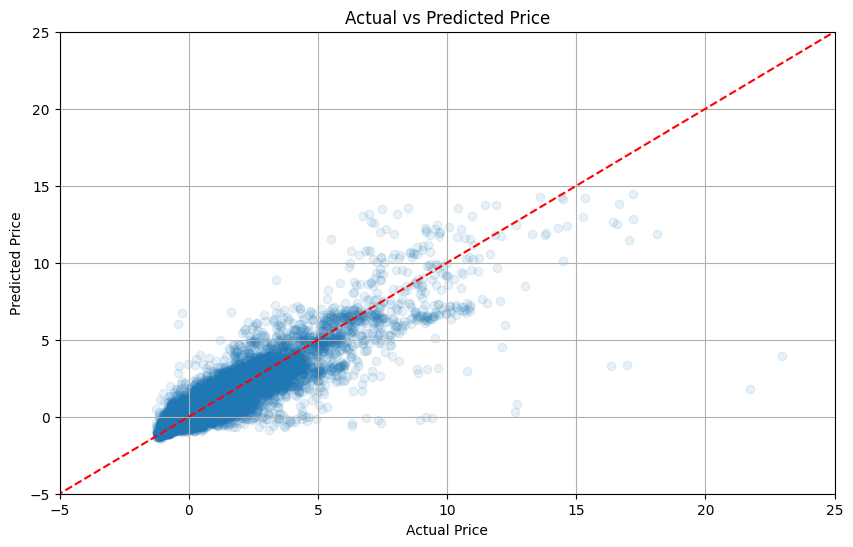

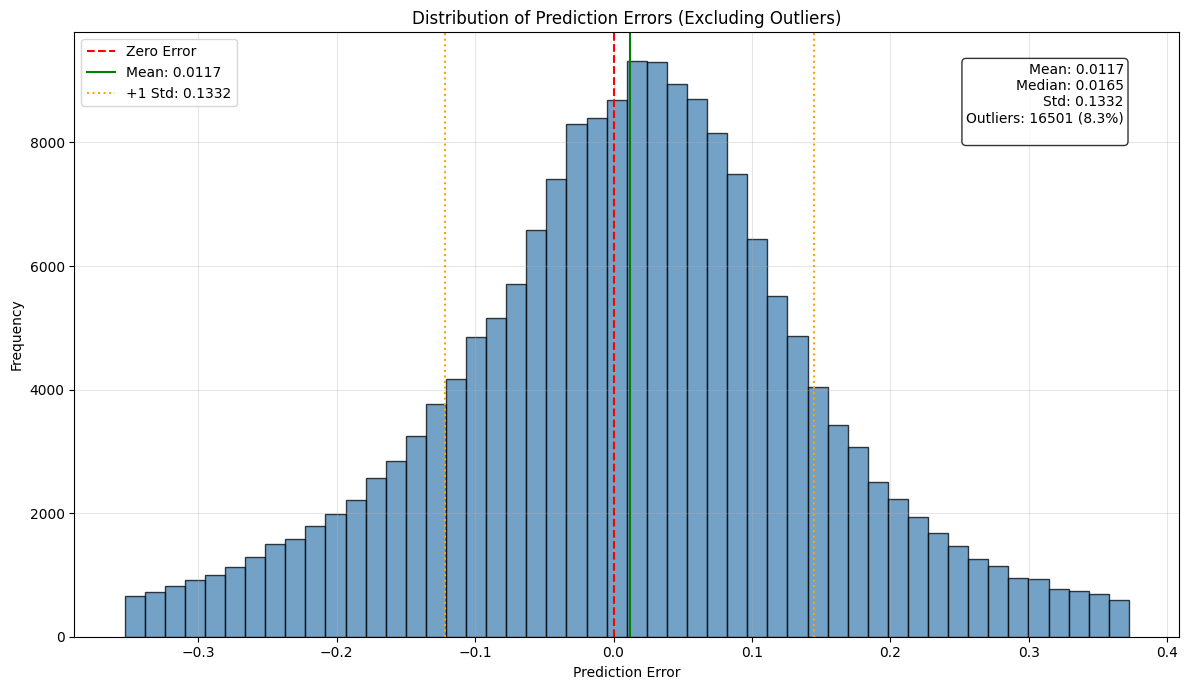

In [54]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(model_path, test_loader, cardinalities, device):
    # Load model
    print(f"Loading model from {model_path}...")
    tab_transformer = TabTransformer(
        categories=tuple(cardinalities),
        num_continuous=len(cont_cols),
        dim=32, depth=4, heads=4, dim_head=16,
        attn_dropout=0.1, ff_dropout=0.1
    )
    model = TabTransformerRegressor(tab_transformer, dim_in=32)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device).eval()
    
    # Evaluation
    all_predictions, all_ground_truth = [], []
    with torch.no_grad():
        for x_cat, x_cont, y_true in test_loader:
            x_cat, x_cont, y_true = x_cat.to(device), x_cont.to(device), y_true.to(device)
            y_pred = model(x_cat, x_cont).squeeze(1)
            all_predictions.extend(y_pred.cpu().numpy())
            all_ground_truth.extend(y_true.cpu().numpy())
    
    # Calculate metrics
    mse = mean_squared_error(all_ground_truth, all_predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(all_ground_truth, all_predictions)
    mae = mean_absolute_error(all_ground_truth, all_predictions)
    
    return mse, rmse, r2, mae, all_predictions, all_ground_truth

# Evaluate model
model_path = "best_tabtransformer_model.pt"
mse, rmse, r2, mae, predictions, ground_truth = evaluate_model(model_path, test_loader, cardinalities, device)

# Print results
print(f"\nEvaluation Results: MSE: {mse:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}, MAE: {mae:.4f}")

# Create visualizations
def plot_results(predictions, ground_truth):
    # Scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(ground_truth, predictions, alpha=0.1)
    plt.plot([-25, 25], [-25, 25], 'r--')
    plt.xlim(-5, 25); plt.ylim(-5, 25)
    plt.xlabel('Actual Price'); plt.ylabel('Predicted Price')
    plt.title('Actual vs Predicted Price')
    plt.grid(True)
    plt.savefig('price_prediction_results.png')
    
    # Error histogram
    errors = np.array(predictions) - np.array(ground_truth)
    q1, q3 = np.percentile(errors, [25, 75])
    iqr = q3 - q1
    lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = errors[(errors < lower_bound) | (errors > upper_bound)]
    filtered_errors = errors[(errors >= lower_bound) & (errors <= upper_bound)]
    
    plt.figure(figsize=(12, 7))
    plt.hist(filtered_errors, bins=50, alpha=0.75, color='steelblue', edgecolor='black')
    
    # Add reference lines
    mean_err, median_error = np.mean(filtered_errors), np.median(filtered_errors)
    std_error = np.std(filtered_errors)
    plt.axvline(x=0, color='r', linestyle='--', linewidth=1.5, label='Zero Error')
    plt.axvline(x=mean_err, color='green', linestyle='-', linewidth=1.5, label=f'Mean: {mean_err:.4f}')
    plt.axvline(x=mean_err + std_error, color='orange', linestyle=':', linewidth=1.5, label=f'+1 Std: {std_error:.4f}')
    plt.axvline(x=mean_err - std_error, color='orange', linestyle=':', linewidth=1.5)
    
    # Add annotations
    stats_text = (f"Mean: {mean_err:.4f}\nMedian: {median_error:.4f}\nStd: {std_error:.4f}\n"
                  f"Outliers: {len(outliers)} ({len(outliers)/len(errors)*100:.1f}%)\n")
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, 
             va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.xlabel('Prediction Error'); plt.ylabel('Frequency')
    plt.title('Distribution of Prediction Errors (Excluding Outliers)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('error_histogram_improved.png')

try:
    plot_results(predictions, ground_truth)
    print("Visualizations saved as 'price_prediction_results.png' and 'error_histogram_improved.png'")
except ImportError:
    print("Matplotlib not available for visualization")

In [55]:


import time
import psutil

# NOTE: this can be used to calculate the elapsed time, CPU time, and memory usage of a block of code however implementation depends on cpu
# so see if you can use it bence. 
class ResourceUsageMonitor:
    def __init__(self):
        self.process = psutil.Process()  # Current process

    def __enter__(self):
        # Record the starting time, CPU times, and memory usage
        self.start_time = time.perf_counter()
        self.start_cpu = self.process.cpu_times()  # returns a named tuple with user and system times
        self.start_memory = self.process.memory_info().rss  # Resident Set Size in bytes
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        # Record the ending metrics
        self.end_time = time.perf_counter()
        self.end_cpu = self.process.cpu_times()
        self.end_memory = self.process.memory_info().rss
        
        # Calculate differences
        self.elapsed_time = self.end_time - self.start_time
        self.cpu_user_time = self.end_cpu.user - self.start_cpu.user
        self.cpu_system_time = self.end_cpu.system - self.start_cpu.system
        self.memory_change = self.end_memory - self.start_memory
        
        # Print the results
        print("Elapsed Wall-Clock Time: {:.2f} seconds".format(self.elapsed_time))
        print("CPU Time (User): {:.2f} seconds".format(self.cpu_user_time))
        print("CPU Time (System): {:.2f} seconds".format(self.cpu_system_time))
        print("Memory Usage Change: {:.2f} MB".format(self.memory_change / (1024 * 1024)))


# Example usage:
with ResourceUsageMonitor() as monitor:
    # Place your long-running code here (e.g., the full notebook execution)
    total = 0
    for i in range(10**7):
        total += i * i
    print("Computation result:", total)

Computation result: 333333283333335000000
Elapsed Wall-Clock Time: 0.91 seconds
CPU Time (User): 0.89 seconds
CPU Time (System): 0.01 seconds
Memory Usage Change: 0.00 MB
